In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import tqdm
import sys
import os

In [ ]:
from sentence_transformers import SentenceTransformer

encoding_model = SentenceTransformer("all-MiniLM-L6-v2")

In [ ]:
import dotenv
import os

config = dotenv.dotenv_values(".env")
replace_keys = ["JAVA_HOME", "FUSEKI_HOME"]
append_keys = ["PATH"]
for key, value in config.items():
    # append to os.environ
    if key in append_keys:
        os.environ[key] = f"{os.environ.get(key, '')}:{value}"
    elif key in replace_keys:
        os.environ[key] = value

# check and compare values in fuseki log
os.environ["OPENBLAS_NUM_THREADS"] = "4"

In [ ]:
sys.path.append(".")

In [ ]:
from utils.datasets import SimpleSet, BerlinSparqlBenchmark
from utils.dbs.qlever import QleverDB
from utils.dbs.fuseki import FusekiDB
from utils.dbs.base_db import BaseDB
from utils.dbs.qlever_native import QleverDBNative
from utils.dbs.fuseki_native import FusekiDBNative
from utils.datasets.base_dataset import QUERY_DIFFICULTY, QUERY_TYPE
from pathlib import Path
import pandas as pd
import numpy as np
from utils.datasets.base_dataset import DataTensor

2026-04-17 19:34:48,190 - INFO - Loading faiss with AVX512 support.
2026-04-17 19:34:48,191 - INFO - Could not load library with AVX512 support due to:
ModuleNotFoundError("No module named 'faiss.swigfaiss_avx512'")
2026-04-17 19:34:48,191 - INFO - Loading faiss with AVX2 support.
2026-04-17 19:34:48,192 - INFO - Could not load library with AVX2 support due to:
ModuleNotFoundError("No module named 'faiss.swigfaiss_avx2'")
2026-04-17 19:34:48,192 - INFO - Loading faiss.
2026-04-17 19:34:48,218 - INFO - Successfully loaded faiss.


In [ ]:
powers = np.arange(0, 6)  # extend on a more powerful machine
sizes = 10**powers

In [ ]:
datasets: dict[int, BerlinSparqlBenchmark] = {}
raw_sizes: dict[int, int] = {}
for power, size in zip(powers, sizes):
    print(f"Running BDSDM generation for size {size}...")
    dataset = BerlinSparqlBenchmark(base_dir=Path(f"./data/bsbm_{power}"), n=size)
    dataset.setup()
    datasets[power] = dataset
    # raw_sizes[power] = dataset.get_triple_count()

2026-04-17 19:34:48,476 - INFO - BSBM dataset already exists in data/bsbm_0, skipping generation
2026-04-17 19:34:48,477 - INFO - BSBM dataset already exists in data/bsbm_1, skipping generation
2026-04-17 19:34:48,477 - INFO - BSBM dataset already exists in data/bsbm_2, skipping generation
2026-04-17 19:34:48,477 - INFO - BSBM dataset already exists in data/bsbm_3, skipping generation
2026-04-17 19:34:48,478 - INFO - BSBM dataset already exists in data/bsbm_4, skipping generation
2026-04-17 19:34:48,478 - INFO - BSBM dataset already exists in data/bsbm_5, skipping generation


Running BDSDM generation for size 1...
Running BDSDM generation for size 10...
Running BDSDM generation for size 100...
Running BDSDM generation for size 1000...
Running BDSDM generation for size 10000...
Running BDSDM generation for size 100000...


In [ ]:
encoded_sizes: dict[int, int] = {}
for power, size in zip(powers, sizes):
    print(f"Encoding dataset of size {size}/power {power}...")
    dataset = datasets[power]
    encoded_sizes[power] = dataset.encode(encoding_model)
    #  dataset.get_triple_count(encoded=True)

Encoding dataset of size 1/power 0...
Encoded TTL file already exists at data/bsbm_0/dataset_encoded.nt, skipping encoding
Encoding dataset of size 10/power 1...
Encoded TTL file already exists at data/bsbm_1/dataset_encoded.nt, skipping encoding
Encoding dataset of size 100/power 2...
Encoded TTL file already exists at data/bsbm_2/dataset_encoded.nt, skipping encoding
Encoding dataset of size 1000/power 3...
Encoded TTL file already exists at data/bsbm_3/dataset_encoded.nt, skipping encoding
Encoding dataset of size 10000/power 4...
Encoded TTL file already exists at data/bsbm_4/dataset_encoded.nt, skipping encoding
Encoding dataset of size 100000/power 5...
Encoded TTL file already exists at data/bsbm_5/dataset_encoded.nt, skipping encoding


## BSBM queries

### Simple Use case: 
find 10 products with a specific encoded label


### Complex Use case: 
For a specific product find 10 other similar products via their product label. 


In [ ]:
test_label = "house furniture storage container"
test_tensor = DataTensor.from_numpy(encoding_model.encode(test_label))

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
test_tensor.to_literal().n3()

'"{\\"data\\": [0.001923849806189537, 0.059069667011499405, -0.06259278953075409, -0.008788925595581532, 0.08017760515213013, 0.0004897266626358032, 0.049011558294296265, -0.016156358644366264, -0.04537816718220711, 0.011929630301892757, -0.003551364177837968, -0.0034783161245286465, 0.023264417424798012, 0.02449001744389534, -0.023595571517944336, -0.073823943734169, 0.014226873405277729, -0.00022305997845251113, -0.03111756220459938, 0.07163400948047638, -0.04559392109513283, 0.044428009539842606, 0.0004388350062072277, -0.004044292028993368, 0.05173112079501152, 0.08436278998851776, -0.028667306527495384, -0.032494205981492996, 0.058949727565050125, -0.0051073553040623665, 0.09506019204854965, -0.029170090332627296, -0.07172352075576782, 0.036426812410354614, 0.01788988709449768, 0.07774496078491211, -0.01058284193277359, -0.02719942107796669, -0.014839782379567623, 0.004996407311409712, -0.05195301026105881, -0.01563340425491333, -0.0004883587826043367, 0.012572054751217365, -0.043

In [ ]:
base_bsbm_set = datasets[2]
db_with_tensor_idx = QleverDBNative(
    id="test",
    base_dir=Path(f"./scratch/bsbm/{base_bsbm_set.base_dir.name}"),
    dataset=base_bsbm_set,
    use_encoded_ttl=True,
)
db_no_tensor_idx = QleverDBNative(
    id="test",
    base_dir=Path(f"./scratch/bsbm/{base_bsbm_set.base_dir.name}"),
    dataset=base_bsbm_set,
    use_encoded_ttl=True,
    enable_tensor_index=False,
)
db_fuseki = FusekiDBNative(
    id="test_fuseki",
    base_dir=Path(f"./scratch/bsbm/{base_bsbm_set.base_dir.name}"),
    dataset=base_bsbm_set,
    use_encoded_ttl=True,
)
possible_queries = db_with_tensor_idx.get_queries(test_tensor)
print(possible_queries)


2026-04-17 19:34:49,645 - WARNING - Killing any existing process using port 26043 before starting the server
2026-04-17 19:34:49,663 - ERROR - Command failed with return code 1
2026-04-17 19:34:49,664 - INFO - Initialized QLeverDBNative with id=test, port_id=26043, dataset=bsbm, name=QLever Native (Extended), use_encoded_ttl=True, endpoint=http://localhost:26043/test-with-tidx/sparql
2026-04-17 19:34:49,665 - WARNING - Killing any existing process using port 26044 before starting the server
2026-04-17 19:34:49,681 - ERROR - Command failed with return code 1
2026-04-17 19:34:49,682 - INFO - Initialized QLeverDBNative with id=test, port_id=26044, dataset=bsbm, name=QLever Native (Extended), use_encoded_ttl=True, endpoint=http://localhost:26044/test-no-tidx/sparql
2026-04-17 19:34:49,683 - WARNING - Killing any existing process using port 29045 before starting the server


2026-04-17 19:34:49,698 - ERROR - Command failed with return code 1


{<QUERY_DIFFICULTY.EASY: 'easy'>: {<QUERY_TYPE.EMBEDDED: 'embedded'>: '\nPREFIX dt: <https://w3id.org/rdf-tensor/datatypes#>\nPREFIX rdf: <http://www.w3.org/2000/01/rdf-schema#>\nPREFIX dtf: <https://w3id.org/rdf-tensor/functions#>\nPREFIX bsbmi: <http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01/instances/>\nSELECT ?product  ?vector ?dist\nWHERE {\n?product rdf:label_embedding ?vector .\nBIND(dtf:cosineSimilarity(?vector, "{\\"data\\": [0.001923849806189537, 0.059069667011499405, -0.06259278953075409, -0.008788925595581532, 0.08017760515213013, 0.0004897266626358032, 0.049011558294296265, -0.016156358644366264, -0.04537816718220711, 0.011929630301892757, -0.003551364177837968, -0.0034783161245286465, 0.023264417424798012, 0.02449001744389534, -0.023595571517944336, -0.073823943734169, 0.014226873405277729, -0.00022305997845251113, -0.03111756220459938, 0.07163400948047638, -0.04559392109513283, 0.044428009539842606, 0.0004388350062072277, -0.004044292028993368, 0.05173112079501152, 0.084

In [ ]:
print(possible_queries[QUERY_DIFFICULTY.EASY][QUERY_TYPE.EMBEDDED])


PREFIX dt: <https://w3id.org/rdf-tensor/datatypes#>
PREFIX rdf: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX dtf: <https://w3id.org/rdf-tensor/functions#>
PREFIX bsbmi: <http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01/instances/>
SELECT ?product  ?vector ?dist
WHERE {
?product rdf:label_embedding ?vector .
BIND(dtf:cosineSimilarity(?vector, "{\"data\": [0.001923849806189537, 0.059069667011499405, -0.06259278953075409, -0.008788925595581532, 0.08017760515213013, 0.0004897266626358032, 0.049011558294296265, -0.016156358644366264, -0.04537816718220711, 0.011929630301892757, -0.003551364177837968, -0.0034783161245286465, 0.023264417424798012, 0.02449001744389534, -0.023595571517944336, -0.073823943734169, 0.014226873405277729, -0.00022305997845251113, -0.03111756220459938, 0.07163400948047638, -0.04559392109513283, 0.044428009539842606, 0.0004388350062072277, -0.004044292028993368, 0.05173112079501152, 0.08436278998851776, -0.028667306527495384, -0.032494205981492996, 0.05894972756505012

In [ ]:
import os
os.getcwd()

'/nfsd/gracedata2/kantz/Dense-Vector-KG/benchmarks'

In [ ]:
import time

with db_no_tensor_idx as db:
    timings = []
    for _ in tqdm.tqdm(range(10)):
        start_time = time.time()
        noised_tensor = test_tensor.to_numpy() + np.random.normal(scale=0.01, size=test_tensor.to_numpy().shape)
        noised_tensor = DataTensor.from_numpy(noised_tensor)

        results = db.query_auto(
            noised_tensor,
            query_difficulty=QUERY_DIFFICULTY.EASY,
            query_type=QUERY_TYPE.EMBEDDED,
        )
        elapsed_time = time.time() - start_time
        timings.append(elapsed_time)
print("Median elapsed time:", np.median(timings))
results

2026-04-17 19:51:58,525 - INFO - Logging QLever setup to scratch/bsbm/bsbm_2/db/test-no-tidx/test-no-tidx_run.log
2026-04-17 19:51:58,527 - INFO - Loading dataset into QLever server from data/bsbm_2/dataset.nt
2026-04-17 19:51:58,528 - WARNING - DB directory scratch/bsbm/bsbm_2/db/test-no-tidx already exists!
2026-04-17 19:51:58,529 - INFO - Stopping server!


2026-04-17 19:51:58,587 - ERROR - Command failed with return code 1
2026-04-17 19:51:58,588 - INFO - Starting QLever server on port 26044
2026-04-17 19:51:58,589 - INFO - Running command: qlever-server -i test-no-tidx --port 26044 -k 0 -m 32G --tensor-search-max-num-threads 4
2026-04-17 19:51:58,593 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:26044/test-no-tidx/sparql)
2026-04-17 19:51:59,609 - INFO - Server is up and responding to queries
100%|██████████| 10/10 [00:00<00:00, 13.94it/s]
2026-04-17 19:52:00,329 - INFO - Stopping server!
2026-04-17 19:52:00,414 - ERROR - Command failed with return code 1


Median elapsed time: 0.0704803466796875


,product,vector,dist
0,bsbmi:ProductFeature553,"{""data"": [0.009423847310245037, -0.01557747554...",0.3191125392914
1,bsbmi:ProductFeature288,"{""data"": [0.010077591054141521, -0.07332565635...",0.3005115687847
2,bsbmi:ProductFeature806,"{""data"": [0.06109052151441574, -0.086534291505...",0.2803135812283
3,bsbmi:ProductFeature911,"{""data"": [0.0399559922516346, 0.04019024968147...",0.279408454895
4,bsbmi:dataFromProducer2/Product85,"{""data"": [0.03998035192489624, 0.0118160368874...",0.2763082683086
5,bsbmi:ProductFeature871,"{""data"": [0.018030863255262375, 0.051510427147...",0.2697617411613
6,bsbmi:ProductType15,"{""data"": [-0.07872356474399567, 0.087168984115...",0.2576656639576
7,bsbmi:dataFromProducer1/Product3,"{""data"": [-0.0035400420892983675, 0.0261042360...",0.2562999725342
8,bsbmi:ProductFeature580,"{""data"": [-0.05134187638759613, -0.03562515974...",0.2521801590919
9,bsbmi:ProductFeature660,"{""data"": [0.07709012180566788, 0.0770644396543...",0.2499122768641


In [ ]:
with db_with_tensor_idx as db:
    possible_queries = db.get_queries(test_tensor)
    results = db.query(possible_queries[QUERY_DIFFICULTY.EASY][QUERY_TYPE.INDEX])
results

2026-04-17 19:49:53,378 - INFO - Logging QLever setup to scratch/bsbm/bsbm_2/db/test-with-tidx/test-with-tidx_run.log
2026-04-17 19:49:53,379 - INFO - Loading dataset into QLever server from data/bsbm_2/dataset.nt
2026-04-17 19:49:53,380 - WARNING - DB directory scratch/bsbm/bsbm_2/db/test-with-tidx already exists!
2026-04-17 19:49:53,380 - INFO - Stopping server!


2026-04-17 19:49:53,444 - ERROR - Command failed with return code 1
2026-04-17 19:49:53,445 - INFO - Starting QLever server on port 26043
2026-04-17 19:49:53,445 - INFO - Running command: qlever-server -i test-with-tidx --port 26043 -k 0 -m 32G --tensor-search-max-num-threads 4
2026-04-17 19:49:53,447 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:26043/test-with-tidx/sparql)
2026-04-17 19:49:54,458 - INFO - Server is up and responding to queries
2026-04-17 19:49:54,566 - INFO - Stopping server!
2026-04-17 19:49:54,636 - ERROR - Command failed with return code 1


,product,vector,dist
0,bsbmi:ProductFeature288,"{""data"": [0.010077591054141521, -0.07332565635...",0.2936039566994
1,bsbmi:ProductFeature806,"{""data"": [0.06109052151441574, -0.086534291505...",0.2798337340355
2,bsbmi:ProductFeature871,"{""data"": [0.018030863255262375, 0.051510427147...",0.2643582522869
3,bsbmi:dataFromProducer2/Product85,"{""data"": [0.03998035192489624, 0.0118160368874...",0.263692855835
4,bsbmi:ProductType15,"{""data"": [-0.07872356474399567, 0.087168984115...",0.2601968050003
5,bsbmi:dataFromProducer1/Product3,"{""data"": [-0.0035400420892983675, 0.0261042360...",0.2591982781887
6,bsbmi:ProductFeature660,"{""data"": [0.07709012180566788, 0.0770644396543...",0.2402602881193
7,bsbmi:dataFromProducer2/Product67,"{""data"": [0.008251700550317764, -0.02543806470...",0.2230883687735
8,bsbmi:ProductFeature4,"{""data"": [0.04077060893177986, 0.0258030090481...",0.221848487854
9,bsbmi:ProductFeature804,"{""data"": [0.026768216863274574, 0.062174364924...",0.22073584795


In [ ]:
with db_fuseki:
    possible_queries = db_fuseki.get_queries(test_tensor)
    results = db_fuseki.query(possible_queries[QUERY_DIFFICULTY.EASY][QUERY_TYPE.EMBEDDED])
results

2026-04-17 15:31:07,989 - WARNING - Killing any existing process using port 29045 before starting the server
2026-04-17 15:31:08,007 - ERROR - Command failed with return code 1
2026-04-17 15:31:08,007 - INFO - Loading dataset into Fuseki server from data/bsbm_2/dataset.nt
2026-04-17 15:31:08,008 - WARNING - DB directory scratch/bsbm/bsbm_2/db/test_fuseki already exists, removing locks if any
2026-04-17 15:31:08,009 - INFO - Stopping server!
2026-04-17 15:31:08,025 - ERROR - Command failed with return code 1
2026-04-17 15:31:08,026 - INFO - Starting Fuseki server port 29045
2026-04-17 15:31:08,027 - ERROR - TENSOR_CP environment variable is not set
2026-04-17 15:31:08,028 - INFO - Using default TENSOR_CP=/nfsd/gracedata2/kantz/Dense-Vector-KG/jena-datatensor/jena-datatensor/target/*
2026-04-17 15:31:08,029 - ERROR - FUSEKI_HOME environment variable is not set
2026-04-17 15:31:08,030 - INFO - Using default FUSEKI_HOME=/home/kantz/apache-jena-fuseki-5.2.0
2026-04-17 15:31:08,030 - INFO - 

 2920161

29045/tcp:          


,product,vector,dist
0,bsbmi:ProductFeature553,"{""data"": [0.009423847310245037, -0.01557747554...",0.31653597950935364
1,bsbmi:ProductFeature288,"{""data"": [0.010077591054141521, -0.07332565635...",0.29360419511795044
2,bsbmi:ProductFeature911,"{""data"": [0.0399559922516346, 0.04019024968147...",0.2867618203163147
3,bsbmi:ProductFeature806,"{""data"": [0.06109052151441574, -0.086534291505...",0.2798336446285248
4,bsbmi:ProductFeature871,"{""data"": [0.018030863255262375, 0.051510427147...",0.26435840129852295
5,bsbmi:dataFromProducer2/Product85,"{""data"": [0.03998035192489624, 0.0118160368874...",0.2636927366256714
6,bsbmi:ProductType15,"{""data"": [-0.07872356474399567, 0.087168984115...",0.26019686460494995
7,bsbmi:dataFromProducer1/Product3,"{""data"": [-0.0035400420892983675, 0.0261042360...",0.25919830799102783
8,bsbmi:ProductFeature580,"{""data"": [-0.05134187638759613, -0.03562515974...",0.24063780903816223
9,bsbmi:ProductFeature660,"{""data"": [0.07709012180566788, 0.0770644396543...",0.24026034772396088


In [ ]:
with db_no_tensor_idx:
    possible_queries = db_no_tensor_idx.get_queries(test_tensor)
    results = db_no_tensor_idx.query(possible_queries[QUERY_DIFFICULTY.EASY][QUERY_TYPE.EMBEDDED])
results

2026-04-17 15:31:11,362 - INFO - Logging QLever setup to scratch/bsbm/bsbm_2/db/test-no-tidx/test-no-tidx_run.log
2026-04-17 15:31:11,363 - INFO - Loading dataset into QLever server from data/bsbm_2/dataset.nt
2026-04-17 15:31:11,364 - WARNING - DB directory scratch/bsbm/bsbm_2/db/test-no-tidx already exists!
2026-04-17 15:31:11,365 - INFO - Stopping server!
2026-04-17 15:31:11,453 - ERROR - Command failed with return code 1
2026-04-17 15:31:11,454 - INFO - Starting QLever server on port 26044
2026-04-17 15:31:11,454 - INFO - Running command: qlever-server -i test-no-tidx --port 26044 -k 0 -m 32G --tensor-search-max-num-threads 4
2026-04-17 15:31:11,456 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:26044/test-no-tidx/sparql)
2026-04-17 15:31:12,468 - INFO - Server is up and responding to queries
2026-04-17 15:31:12,527 - INFO - Stopping server!
2026-04-17 15:31:12,621 - ERROR - Command failed with return code 1


,product,vector,dist
0,bsbmi:ProductFeature553,"{""data"": [0.009423847310245037, -0.01557747554...",0.3165358603001
1,bsbmi:ProductFeature288,"{""data"": [0.010077591054141521, -0.07332565635...",0.2936039566994
2,bsbmi:ProductFeature911,"{""data"": [0.0399559922516346, 0.04019024968147...",0.2867618203163
3,bsbmi:ProductFeature806,"{""data"": [0.06109052151441574, -0.086534291505...",0.2798337340355
4,bsbmi:ProductFeature871,"{""data"": [0.018030863255262375, 0.051510427147...",0.2643582224846
5,bsbmi:dataFromProducer2/Product85,"{""data"": [0.03998035192489624, 0.0118160368874...",0.263692855835
6,bsbmi:ProductType15,"{""data"": [-0.07872356474399567, 0.087168984115...",0.2601968050003
7,bsbmi:dataFromProducer1/Product3,"{""data"": [-0.0035400420892983675, 0.0261042360...",0.2591982781887
8,bsbmi:ProductFeature580,"{""data"": [-0.05134187638759613, -0.03562515974...",0.2406378388405
9,bsbmi:ProductFeature660,"{""data"": [0.07709012180566788, 0.0770644396543...",0.2402603030205


In [ ]:
import os
os.environ["PATH"]

'/nfsd/gracedata2/kantz/Dense-Vector-KG/.venv/bin:/nfsd/gracedata2/kantz/Dense-Vector-KG/.venv/bin:/nfsd/gracedata2/kantz/Dense-Vector-KG/qlever/build/release:/home/kantz/apache-jena-fuseki-5.2.0:/home/kantz/apache-jena-5.2.0/bin:/home/kantz/miniconda3/envs/qlever/bin:/home/kantz/.vscode-server/data/User/globalStorage/github.copilot-chat/debugCommand:/home/kantz/.vscode-server/data/User/globalStorage/github.copilot-chat/copilotCli:/home/kantz/.vscode-server/cli/servers/Stable-cfbea10c5ffb233ea9177d34726e6056e89913dc/server/bin/remote-cli:/home/kantz/bin:/home/kantz/bin:/home/kantz/.local/bin:/usr/share/Modules/bin:/usr/condabin:/usr/local/bin:/usr/bin:/usr/local/sbin:/usr/sbin:/usr/java/latest/bin:/usr/lib/scala/bin:/usr/local/spark-2.3.2-bin-hadoop2.7/bin:/usr/java/latest/bin:/usr/lib/scala/bin:/usr/local/spark-2.3.2-bin-hadoop2.7/bin:/home/kantz/.vscode-server/extensions/ms-python.debugpy-2025.18.0-linux-x64/bundled/scripts/noConfigScripts:/home/kantz/.vscode-server/cli/servers/Stabl

In [ ]:
with db:
    count=db.query("SELECT (COUNT(*) AS ?count) WHERE { ?s ?p ?o }")
print(count)

2026-04-17 15:31:12,736 - INFO - Logging QLever setup to scratch/bsbm/bsbm_2/db/test-no-tidx/test-no-tidx_run.log
2026-04-17 15:31:12,736 - INFO - Loading dataset into QLever server from data/bsbm_2/dataset.nt
2026-04-17 15:31:12,737 - WARNING - DB directory scratch/bsbm/bsbm_2/db/test-no-tidx already exists!
2026-04-17 15:31:12,737 - INFO - Stopping server!
2026-04-17 15:31:12,828 - ERROR - Command failed with return code 1
2026-04-17 15:31:12,829 - INFO - Starting QLever server on port 26044
2026-04-17 15:31:12,830 - INFO - Running command: qlever-server -i test-no-tidx --port 26044 -k 0 -m 32G --tensor-search-max-num-threads 4
2026-04-17 15:31:12,832 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:26044/test-no-tidx/sparql)
2026-04-17 15:31:13,843 - INFO - Server is up and responding to queries
2026-04-17 15:31:13,850 - INFO - Stopping server!
2026-04-17 15:31:13,941 - ERROR - Command failed with return code 1


   count
0  42417


In [ ]:
counts=[]
for power, size in zip(powers, sizes):
    difficulties = [
        QUERY_DIFFICULTY.HARD,
        QUERY_DIFFICULTY.EASY,
    ]
    dataset = datasets[power]
    db = QleverDBNative(
        id="timing-qlever",
        base_dir=Path(f"./scratch/bsbm/{dataset.base_dir.name}"),
        dataset=dataset,
        use_encoded_ttl=True,
    )
    with db:
        full_number_of_tensors = db.query("""
PREFIX rdf: <http://www.w3.org/2000/01/rdf-schema#>
SELECT (COUNT(?v) AS ?count) WHERE {
    {
    SELECT ?s ?v WHERE {          
    ?s rdf:label_embedding ?v .
    }
    } UNION {
            SELECT ?s ?v WHERE {
        ?s rdf:comment_embedding ?v .}
    }
}
""")["count"].values[0]
        full_size = db.get_triple_count()
        counts.append({
            "power": power,
            "size": size,
            "full_size": full_size,
            "full_number_of_tensors": full_number_of_tensors,
        })
counts_df = pd.DataFrame(counts)
counts_df

2026-04-17 17:08:59,387 - WARNING - Killing any existing process using port 26087 before starting the server
2026-04-17 17:08:59,409 - ERROR - Command failed with return code 1
2026-04-17 17:08:59,410 - INFO - Initialized QLeverDBNative with id=timing-qlever, port_id=26087, dataset=bsbm, name=QLever Native (Extended), use_encoded_ttl=True, endpoint=http://localhost:26087/timing-qlever-with-tidx/sparql
2026-04-17 17:08:59,410 - INFO - Logging QLever setup to scratch/bsbm/bsbm_0/db/timing-qlever-with-tidx/timing-qlever-with-tidx_run.log
2026-04-17 17:08:59,411 - INFO - Loading dataset into QLever server from data/bsbm_0/dataset.nt
2026-04-17 17:08:59,412 - WARNING - DB directory scratch/bsbm/bsbm_0/db/timing-qlever-with-tidx already exists!
2026-04-17 17:08:59,412 - INFO - Stopping server!
2026-04-17 17:08:59,430 - ERROR - Command failed with return code 1
2026-04-17 17:08:59,430 - INFO - Starting QLever server on port 26087
2026-04-17 17:08:59,431 - INFO - Running command: qlever-server

,power,size,full_size,full_number_of_tensors
0,0,1,2418,576
1,1,10,5595,608
2,2,100,42417,2240
3,3,1000,383751,11840
4,4,10000,3577077,42304
5,5,100000,35177974,305792


In [ ]:
counts_df = counts_df.astype(int)
counts_df

,power,size,full_size,full_number_of_tensors
0,0,1,2418,576
1,1,10,5595,608
2,2,100,42417,2240
3,3,1000,383751,11840
4,4,10000,3577077,42304
5,5,100000,35177974,305792


In [ ]:
out_dir = Path("./scratch/results")
out_dir.mkdir(parents=True, exist_ok=True)
from utils.helpers import pretty_print_counts
pretty_print_counts(counts_df, out_dir / "bsbm_counts.tex")

,Power,Generation $t$,$n$,$n_{tensors}$
0,0,1,2418,576
1,1,10,5595,608
2,2,100,42417,2240
3,3,1000,383751,11840
4,4,10000,3577077,42304
5,5,100000,35177974,305792


## Try some timings!

In [ ]:
import pandas as pd

from utils.dbs.base_docker import BaseDocker
from utils.bench import BenchmarkRunner

timings_df = pd.DataFrame()
stats_df = pd.DataFrame()
offset = 0
for power, size in zip(powers, sizes):
    difficulties = [
        QUERY_DIFFICULTY.HARD,
        QUERY_DIFFICULTY.EASY,
    ]
    print(f"Running BDSDM timing for size {size}...")
    dataset = datasets[power]
    dbs: list[BaseDocker] = [
        FusekiDBNative(
            id="timing-fuseki",
            base_dir=Path(f"./scratch/bsbm/{dataset.base_dir.name}"),
            dataset=dataset,
            use_encoded_ttl=True,
            port_offset=offset
        ),
        QleverDBNative(
            id="timing-qlever",
            base_dir=Path(f"./scratch/bsbm/{dataset.base_dir.name}"),
            dataset=dataset,
            use_encoded_ttl=True,
            enable_tensor_index=True,
            name="Qlever",
            port_offset=offset + 1
        ),
        QleverDBNative(
            id="timing-qlever",
            base_dir=Path(f"./scratch/bsbm/{dataset.base_dir.name}"),
            dataset=dataset,
            use_encoded_ttl=True,
            enable_tensor_index=False,
            name="Qlever (no Tensor Vocabulary)",
            port_offset=offset + 2,
        ),
    ]
    reference_db = dbs[0]
    reference_results: dict[QUERY_DIFFICULTY, pd.DataFrame] = {}
    for difficulty in difficulties:
        try:
            with reference_db:
                reference_result = reference_db.query_auto(
                    test_tensor,
                    query_difficulty=difficulty,
                    query_type=QUERY_TYPE.EMBEDDED,
                )
                reference_results[difficulty] = reference_result
        except Exception as e:
            print(f"Error occurred while querying reference DB for difficulty {difficulty}: {e}")
    bench = BenchmarkRunner(
        dbs=dbs,
        test_tensor=test_tensor,
        difficulties=difficulties,
        types=[
            QUERY_TYPE.EMBEDDED,
            QUERY_TYPE.INDEX,
        ],
        dataset=dataset,
        reference_results=reference_results,
    )
    result = bench.run_benchmark(repetitions=128)
    timings_df = pd.concat([timings_df, result.timings], ignore_index=True)
    stats_df = pd.concat([stats_df, result.stats], ignore_index=True)
    offset += len(dbs)

2026-04-17 15:31:14,016 - WARNING - Killing any existing process using port 29046 before starting the server
2026-04-17 15:31:14,034 - ERROR - Command failed with return code 1
2026-04-17 15:31:14,035 - WARNING - Killing any existing process using port 26048 before starting the server
2026-04-17 15:31:14,051 - ERROR - Command failed with return code 1
2026-04-17 15:31:14,052 - INFO - Initialized QLeverDBNative with id=timing-qlever, port_id=26048, dataset=bsbm, name=Qlever, use_encoded_ttl=True, endpoint=http://localhost:26048/timing-qlever-with-tidx/sparql
2026-04-17 15:31:14,053 - WARNING - Killing any existing process using port 26050 before starting the server
2026-04-17 15:31:14,069 - ERROR - Command failed with return code 1
2026-04-17 15:31:14,070 - INFO - Initialized QLeverDBNative with id=timing-qlever, port_id=26050, dataset=bsbm, name=Qlever (no Tensor Vocabulary), use_encoded_ttl=True, endpoint=http://localhost:26050/timing-qlever-no-tidx/sparql
2026-04-17 15:31:14,071 - WA

Running BDSDM timing for size 1...


2026-04-17 15:31:15,933 - INFO - Server is up and responding to queries
2026-04-17 15:31:16,393 - INFO - Stopping server!
29046/tcp:          
2026-04-17 15:31:16,493 - WARNING - Killing any existing process using port 29046 before starting the server
2026-04-17 15:31:16,587 - ERROR - Command failed with return code 1
2026-04-17 15:31:16,588 - INFO - Loading dataset into Fuseki server from data/bsbm_0/dataset.nt
2026-04-17 15:31:16,590 - WARNING - DB directory scratch/bsbm/bsbm_0/db/timing-fuseki already exists, removing locks if any
2026-04-17 15:31:16,591 - INFO - Stopping server!
2026-04-17 15:31:16,675 - ERROR - Command failed with return code 1
2026-04-17 15:31:16,676 - INFO - Starting Fuseki server port 29046
2026-04-17 15:31:16,677 - ERROR - TENSOR_CP environment variable is not set
2026-04-17 15:31:16,678 - INFO - Using default TENSOR_CP=/nfsd/gracedata2/kantz/Dense-Vector-KG/jena-datatensor/jena-datatensor/target/*
2026-04-17 15:31:16,679 - ERROR - FUSEKI_HOME environment vari

 2920433

2026-04-17 15:31:18,472 - INFO - Server is up and responding to queries
2026-04-17 15:31:19,397 - INFO - Stopping server!
29046/tcp:          
2026-04-17 15:31:19,490 - WARNING - Killing any existing process using port 29046 before starting the server
2026-04-17 15:31:19,580 - ERROR - Command failed with return code 1
2026-04-17 15:31:19,580 - INFO - Loading dataset into Fuseki server from data/bsbm_0/dataset.nt
2026-04-17 15:31:19,581 - WARNING - DB directory scratch/bsbm/bsbm_0/db/timing-fuseki already exists, removing locks if any
2026-04-17 15:31:19,582 - INFO - Stopping server!
2026-04-17 15:31:19,673 - ERROR - Command failed with return code 1
2026-04-17 15:31:19,673 - INFO - Starting Fuseki server port 29046
2026-04-17 15:31:19,674 - ERROR - TENSOR_CP environment variable is not set
2026-04-17 15:31:19,675 - INFO - Using default TENSOR_CP=/nfsd/gracedata2/kantz/Dense-Vector-KG/jena-datatensor/jena-datatensor/target/*
2026-04-17 15:31:19,675 - ERROR - FUSEKI_HOME environment vari

...

 2920859Running benchmark for FusekiDB + RDFTensor, difficulty hard, query type index


2026-04-17 15:31:23,874 - ERROR - TENSOR_CP environment variable is not set
2026-04-17 15:31:23,874 - INFO - Using default TENSOR_CP=/nfsd/gracedata2/kantz/Dense-Vector-KG/jena-datatensor/jena-datatensor/target/*
2026-04-17 15:31:23,875 - ERROR - FUSEKI_HOME environment variable is not set
2026-04-17 15:31:23,875 - INFO - Using default FUSEKI_HOME=/home/kantz/apache-jena-fuseki-5.2.0
2026-04-17 15:31:23,876 - INFO - Using FUSEKI_HOME=/home/kantz/apache-jena-fuseki-5.2.0 and TENSOR_CP=/nfsd/gracedata2/kantz/Dense-Vector-KG/jena-datatensor/jena-datatensor/target/*
2026-04-17 15:31:23,877 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:29046/timing-fuseki/sparql)
2026-04-17 15:31:25,596 - INFO - Server is up and responding to queries
2026-04-17 15:31:25,627 - INFO - Stopping server!
29046/tcp:          
2026-04-17 15:31:25,725 - WARNING - Killing any existing process using port 29046 before starting the server


Query type QUERY_TYPE.INDEX not available for FusekiDB + RDFTensor, skipping.
 2921159Running benchmark for FusekiDB + RDFTensor, difficulty easy, query type embedded


2026-04-17 15:31:25,828 - ERROR - Command failed with return code 1
2026-04-17 15:31:25,829 - INFO - Loading dataset into Fuseki server from data/bsbm_0/dataset.nt
2026-04-17 15:31:25,829 - WARNING - DB directory scratch/bsbm/bsbm_0/db/timing-fuseki already exists, removing locks if any
2026-04-17 15:31:25,830 - INFO - Stopping server!
2026-04-17 15:31:25,929 - ERROR - Command failed with return code 1
2026-04-17 15:31:25,930 - INFO - Starting Fuseki server port 29046
2026-04-17 15:31:25,931 - ERROR - TENSOR_CP environment variable is not set
2026-04-17 15:31:25,931 - INFO - Using default TENSOR_CP=/nfsd/gracedata2/kantz/Dense-Vector-KG/jena-datatensor/jena-datatensor/target/*
2026-04-17 15:31:25,932 - ERROR - FUSEKI_HOME environment variable is not set
2026-04-17 15:31:25,932 - INFO - Using default FUSEKI_HOME=/home/kantz/apache-jena-fuseki-5.2.0
2026-04-17 15:31:25,933 - INFO - Using FUSEKI_HOME=/home/kantz/apache-jena-fuseki-5.2.0 and TENSOR_CP=/nfsd/gracedata2/kantz/Dense-Vector-KG

KeyboardInterrupt: 

In [ ]:
with dbs[1] as db:
    result = db.query_auto(
        test_tensor,
        query_difficulty=QUERY_DIFFICULTY.HARD,
        query_type=QUERY_TYPE.EMBEDDED,
    )
result

2026-04-17 15:37:52,330 - INFO - Logging QLever setup to scratch/bsbm/bsbm_0/db/timing-qlever-with-tidx/timing-qlever-with-tidx_run.log
2026-04-17 15:37:52,331 - INFO - Loading dataset into QLever server from data/bsbm_0/dataset.nt
2026-04-17 15:37:52,332 - WARNING - DB directory scratch/bsbm/bsbm_0/db/timing-qlever-with-tidx already exists!
2026-04-17 15:37:52,332 - INFO - Stopping server!
2026-04-17 15:37:52,428 - ERROR - Command failed with return code 1
2026-04-17 15:37:52,429 - INFO - Starting QLever server on port 26048
2026-04-17 15:37:52,430 - INFO - Running command: qlever-server -i timing-qlever-with-tidx --port 26048 -k 0 -m 32G --tensor-search-max-num-threads 4
2026-04-17 15:37:52,431 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:26048/timing-qlever-with-tidx/sparql)
2026-04-17 15:37:53,441 - INFO - Server is up and responding to queries
2026-04-17 15:37:53,473 - INFO - Stopping server!
2026-04-17 15:37:

""


In [ ]:
timings_df["size"].unique()

array([   2418,    5595,   42417,  383751, 3577077])

In [ ]:
timings_df.to_csv("./scratch/bdsdm_timings.csv", index=False)
timings_df["engine"].unique()

<ArrowStringArray>
['FusekiDB + RDFTensor', 'Qlever', 'Qlever (no Tensor Vocabulary)']
Length: 3, dtype: str

In [ ]:
engines = timings_df["engine"].unique()
difficulties = timings_df["difficulty"].unique()

In [ ]:
groupings = timings_df.groupby(["estimated_size", "engine", "difficulty", "query_type"])[
    "elapsed_time"
]
quantiles = [0.05, 0.95]
median_timings = groupings.median().reset_index()
quantile_timings = groupings.quantile(quantiles).unstack().reset_index()

In [ ]:
colors = {eng: color for eng, color in zip(engines, ["C0", "C1", "C2", "C3", "C4"])}
colors

{'FusekiDB + RDFTensor': 'C0',
 'Qlever': 'C1',
 'Qlever (no Tensor Vocabulary)': 'C2'}

/tmp/ipykernel_1791123/2830796753.py:28: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(


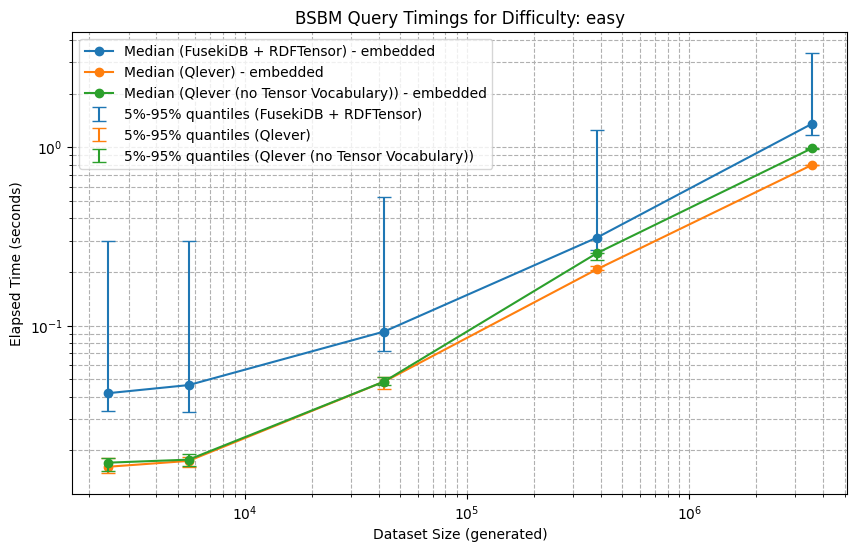

In [ ]:
import matplotlib.pyplot as plt


# plot the timings as double-log plot with error bars for the 5% and 95% quantiles
def plot_timings(ax, df, engine, difficulty, relevant_measure="elapsed_time"):
    groupings = df.groupby(["size", "engine", "difficulty", "query_type"])[
        relevant_measure
    ]
    quantiles = [0.05, 0.95]
    median_timings = groupings.median().reset_index()
    quantile_timings = groupings.quantile(quantiles).unstack().reset_index()
    for query_type in QUERY_TYPE:
        for engine in median_timings["engine"].unique():
            engine_median = median_timings[
                (median_timings["query_type"] == query_type.value)
                & (median_timings["difficulty"] == difficulty)
                & (median_timings["engine"] == engine)
            ]
            engine_quantiles = quantile_timings[
                (quantile_timings["query_type"] == query_type.value)
                & (quantile_timings["difficulty"] == difficulty)
                & (quantile_timings["engine"] == engine)
            ]
            if engine_median.empty or engine_quantiles.empty:
                continue
            # index are dashed, embedded are solid
            linestyle = "--" if query_type == QUERY_TYPE.INDEX else "-"
            ax.plot(
                engine_median["size"],
                engine_median[relevant_measure],
                "o-",
                linestyle=linestyle,
                label=f"Median ({engine}) - {query_type.value}",
                color=colors[engine],
            )
            ax.errorbar(
                engine_median["size"],
                engine_median[relevant_measure],
                yerr=[
                    engine_median[relevant_measure] - engine_quantiles[0.05],
                    engine_quantiles[0.95] - engine_median[relevant_measure],
                ],
                barsabove=True,
                capsize=5,
                fmt="none",
                label=f"5%-95% quantiles ({engine})",
                color=colors[engine],
            )


fig, axes = plt.subplots(len(difficulties), 1, figsize=(10, 6 * len(difficulties)))
for i, difficulty in enumerate(difficulties):
    ax = axes[i] if len(difficulties) > 1 else axes
    # set the subtitle to the difficulty

    plot_timings(ax, timings_df, engines, difficulty)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Dataset Size (generated)")
    ax.set_ylabel("Elapsed Time (seconds)")
    ax.set_title(f"BSBM Query Timings for Difficulty: {difficulty}")
    ax.legend()
    ax.grid(True, which="both", ls="--")
plt.savefig("./scratch/bsbm_timings.png")
plt.show()

In [ ]:
stats_df

,timestamp,cpu_percent,mem_usage,net_io,block_io,pids,size,power,difficulty,query_type,estimated_size,engine
0,2026-04-16 18:28:05.374723,0.0,371515392,-1,-1,1,2418,3,easy,embedded,1,FusekiDB + RDFTensor
1,2026-04-16 18:28:05.507377,701.4,389615616,-1,-1,1,2418,3,easy,embedded,1,FusekiDB + RDFTensor
2,2026-04-16 18:28:05.639975,625.9,402489344,-1,-1,1,2418,3,easy,embedded,1,FusekiDB + RDFTensor
3,2026-04-16 18:28:05.773173,1208.8,424935424,-1,-1,1,2418,3,easy,embedded,1,FusekiDB + RDFTensor
4,2026-04-16 18:28:05.908820,1931.5,445562880,-1,-1,1,2418,3,easy,embedded,1,FusekiDB + RDFTensor
...,...,...,...,...,...,...,...,...,...,...,...,...
621,2026-04-16 18:30:14.343154,96.0,116125696,-1,-1,1,3577077,6,easy,embedded,10000,Qlever (no Tensor Vocabulary)
622,2026-04-16 18:30:14.468313,103.9,116125696,-1,-1,1,3577077,6,easy,embedded,10000,Qlever (no Tensor Vocabulary)
623,2026-04-16 18:30:14.593441,95.9,116125696,-1,-1,1,3577077,6,easy,embedded,10000,Qlever (no Tensor Vocabulary)
624,2026-04-16 18:30:14.718691,95.8,116125696,-1,-1,1,3577077,6,easy,embedded,10000,Qlever (no Tensor Vocabulary)


In [ ]:
stats_df["cpu_percent"] = stats_df["cpu_percent"].astype(float)
stats_df["mem_usage_mb"] = stats_df["mem_usage"].astype(float) / (1024 * 1024)  # in MiB

/tmp/ipykernel_1791123/2830796753.py:28: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(


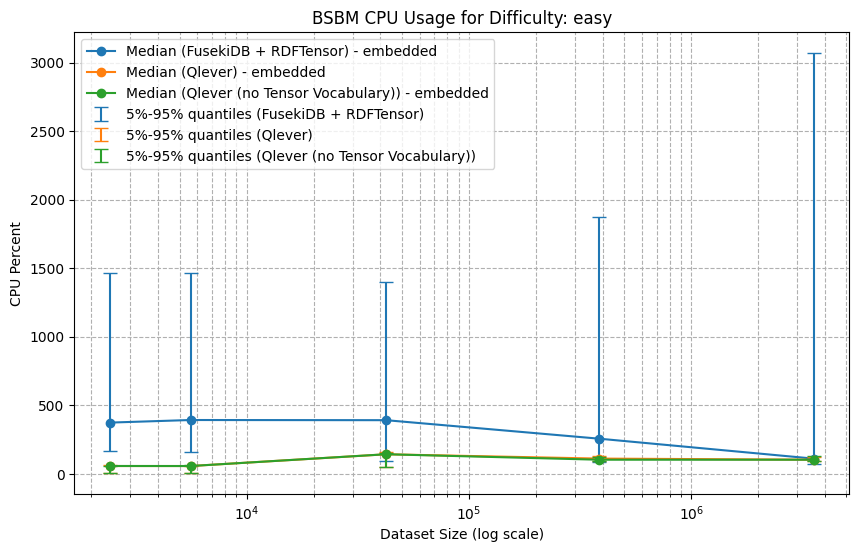

In [ ]:
# plot the stats for the same runs, e.g. number of triples scanned, number of candidates, etc.


fig, axes = plt.subplots(len(difficulties), 1, figsize=(10, 6 * len(difficulties)))
for i, difficulty in enumerate(difficulties):
    ax = axes[i] if len(difficulties) > 1 else axes
    # set the subtitle to the difficulty

    plot_timings(ax, stats_df, engines, difficulty, relevant_measure="cpu_percent")
    ax.set_xscale("log")
    ax.set_xlabel("Dataset Size (log scale)")
    ax.set_ylabel("CPU Percent")
    ax.set_title(f"BSBM CPU Usage for Difficulty: {difficulty}")
    ax.legend()
    ax.grid(True, which="both", ls="--")
plt.savefig("./scratch/bsbm_cpu_usage.png")
plt.show()


/tmp/ipykernel_1791123/2830796753.py:28: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(


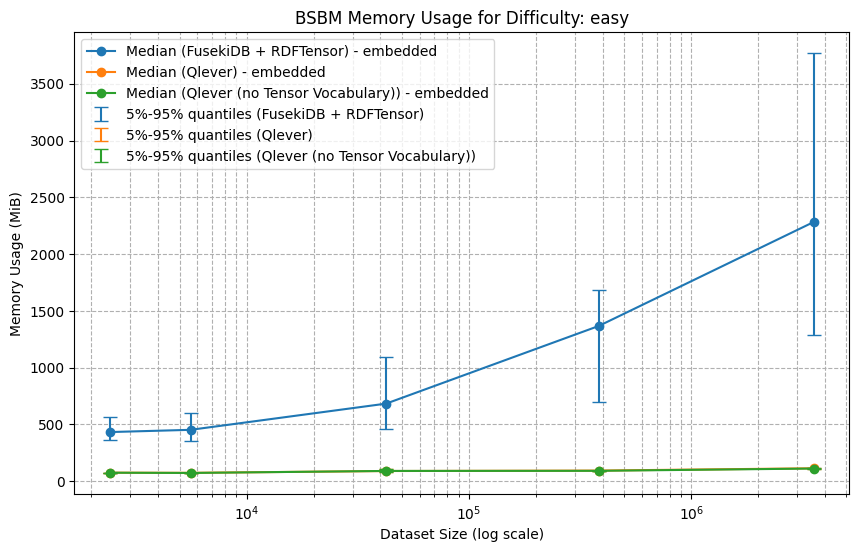

In [ ]:
# plot the stats for the same runs, e.g. number of triples scanned, number of candidates, etc.


fig, axes = plt.subplots(len(difficulties), 1, figsize=(10, 6 * len(difficulties)))
for i, difficulty in enumerate(difficulties):
    ax = axes[i] if len(difficulties) > 1 else axes
    # set the subtitle to the difficulty

    plot_timings(ax, stats_df, engines, difficulty, relevant_measure="mem_usage_mb")
    ax.set_xscale("log")
    ax.set_xlabel("Dataset Size (log scale)")
    ax.set_ylabel("Memory Usage (MiB)")
    ax.set_title(f"BSBM Memory Usage for Difficulty: {difficulty}")
    ax.legend()
    ax.grid(True, which="both", ls="--")
plt.savefig("./scratch/bsbm_mem_usage.png")
plt.show()
